# Week 2 — Data Preprocessing & Feature Engineering
## Loan Approval Prediction

### Objective

The objective of this notebook is to prepare the loan application dataset for
machine learning by performing:

- Dataset inspection and quality assessment
- Missing-value analysis and imputation
- Removal of non-predictive identifiers
- Domain-driven feature engineering
- Categorical variable encoding
- Numerical feature scaling
- Correlation analysis
- Final preprocessing validation

The project provides two separate datasets:

- `loan_dataset_train.csv`: training data containing the target variable
- `loan_dataset_test.csv`: test data without the target variable

The preprocessing parameters are learned **exclusively from the training set**
and subsequently applied to the test set to prevent data leakage.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

os.makedirs("../plots", exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## 2. Dataset Loading

The project provides separate training and test datasets. Therefore, no
additional train/test split is required.

The training dataset contains the target variable `Loan_Status`, whereas
the test dataset contains only the explanatory variables.

In [2]:
train_df = pd.read_csv("../data/loan_dataset_train.csv")
test_df = pd.read_csv("../data/loan_dataset_test.csv")

print(f"Training set shape : {train_df.shape}")
print(f"Test set shape     : {test_df.shape}")

Training set shape : (614, 13)
Test set shape     : (367, 12)


In [3]:
display(train_df.head())
display(test_df.head())

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.000,NaN,360.000,1.000,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.000,128.000,360.000,1.000,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.000,66.000,360.000,1.000,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.000,120.000,360.000,1.000,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.000,141.000,360.000,1.000,Urban,Y


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.000,360.000,1.000,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.000,360.000,1.000,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.000,360.000,1.000,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.000,360.000,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.000,360.000,1.000,Urban


## 3. Initial Dataset Inspection

Before modifying the data, we inspect:

- dimensions
- data types
- missing values
- duplicate observations
- basic descriptive statistics

This establishes the initial data quality and provides a baseline for
evaluating the preprocessing steps.

In [4]:
def prepare_dependents(df):
    df = df.copy()
    df["Dependents"] = (df["Dependents"].replace("3+", 3).astype(int))

    return df

def add_engineered_features(df):
    df = df.copy()

    df["totalIncome"] = (df["ApplicantIncome"] + df["CoapplicantIncome"])

    df["incomePerDependent"] = (df["totalIncome"] /(df['Dependents'].replace('3+', 3).astype(int) + 1))

    df["loanToIncomeRatio"] = (df["LoanAmount"] / df["totalIncome"].replace(0, np.nan))

    return df


def global_dataset_overview(df, name="Dataset"):
    print("=" * 65)
    print(f"\t\t\t\t\t{name.upper()} OVERVIEW")
    print("=" * 65)
    print(f"Rows    : {df.shape[0]:,}")
    print(f"Columns : {df.shape[1]:,}")
    print(f"Duplicates : {df.duplicated().sum():,}")

    missing_by_col = df.isna().sum()
    missing_by_col = missing_by_col[missing_by_col > 0].sort_values(ascending=False)

    if len(missing_by_col):
        summary = pd.DataFrame({
            "Missing": missing_by_col,
            "Percentage": (missing_by_col / len(df) * 100).round(2)
        })
        print(f"\nTotal missing values : {missing_by_col.sum():,} present in {len(missing_by_col[missing_by_col > 0])} columns")
        display(summary)
    else:
        print("No missing values detected.")

In [5]:
global_dataset_overview(train_df, "Training Dataset")

					TRAINING DATASET OVERVIEW
Rows    : 614
Columns : 13
Duplicates : 0

Total missing values : 149 present in 7 columns


,Missing,Percentage
Credit_History,50,8.140
Self_Employed,32,5.210
LoanAmount,22,3.580
Dependents,15,2.440
Loan_Amount_Term,14,2.280
Gender,13,2.120
Married,3,0.490


In [6]:
global_dataset_overview(test_df, "Test Dataset")

					TEST DATASET OVERVIEW
Rows    : 367
Columns : 12
Duplicates : 0

Total missing values : 84 present in 6 columns


,Missing,Percentage
Credit_History,29,7.900
Self_Employed,23,6.270
Gender,11,3.000
Dependents,10,2.720
Loan_Amount_Term,6,1.630
LoanAmount,5,1.360


## 4. Data Types and Feature Classification

Understanding the data types is necessary before choosing an appropriate
preprocessing strategy.

Variables are classified into:

- numerical features
- categorical features
- identifier columns
- target variable

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
display(cat_cols)
display(num_cols)

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

In [9]:
target_col = "Loan_Status"
id_col = "Loan_ID"

categorical_cols = ["Gender","Married","Dependents","Education","Self_Employed","Property_Area"]
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]

print("Categorical features:")
print(categorical_cols)

print("\nNumerical features:")
print(numeric_cols)

Categorical features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

Numerical features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


## 5. Target Variable Analysis

The target variable is `Loan_Status`, representing whether the loan
application was approved.

Before preprocessing, it's class distribution is examined to identify
potential class imbalance.

In [10]:
target_distribution = train_df["Loan_Status"].value_counts()
target_proportions = train_df["Loan_Status"].value_counts(normalize=True) * 100
print(target_distribution)
print('='*30)
print(target_proportions)

Loan_Status
Y    422
N    192
Name: count, dtype: int64
Loan_Status
Y   68.730
N   31.270
Name: proportion, dtype: float64


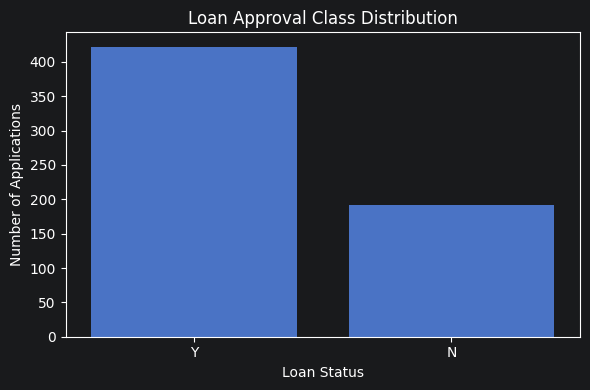

In [41]:
plt.figure(figsize=(6, 4))

sns.countplot(data=train_df,x="Loan_Status")

plt.title("Loan Approval Class Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.tight_layout()

plt.savefig("plots/target_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## 6. Missing Value Analysis

Missing values are present in several variables, including:

- `Credit_History`
- `Self_Employed`
- `LoanAmount`
- `Dependents`
- `Loan_Amount_Term`
- `Gender`
- `Married`

The training dataset contains 149 missing values before preprocessing.

The imputation strategy will be selected according to the variable type:

- categorical/discrete variables -> mode
- continuous numerical variable -> median

The median is preferred for `LoanAmount` because the variable contains
large values and is therefore sensitive to outliers.

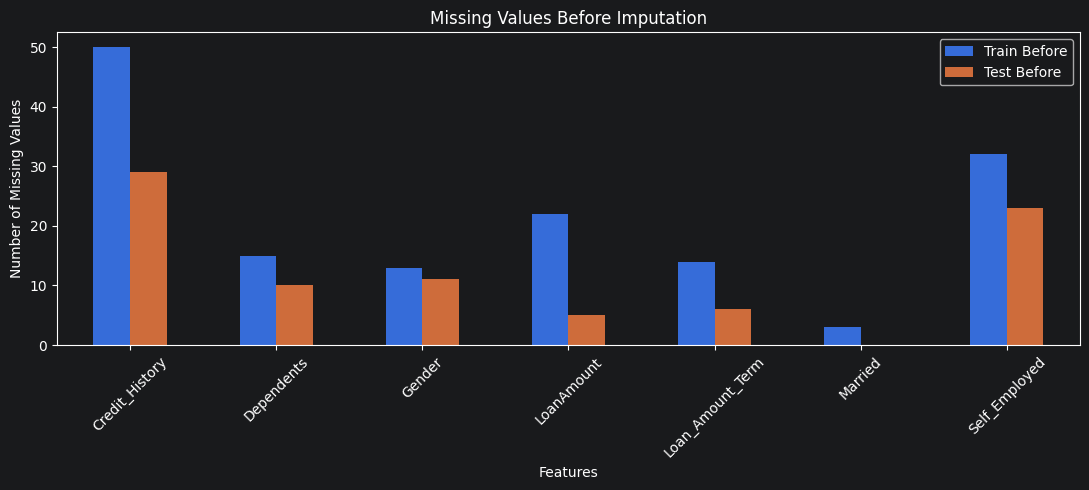

In [12]:
missing_before_train = train_df.isna().sum()
missing_before_test = test_df.isna().sum()
missing_comparison = pd.DataFrame({
    "Train Before": missing_before_train,
    "Test Before": missing_before_test
})

missing_comparison = missing_comparison[missing_comparison.sum(axis=1) > 0]

missing_comparison.plot(kind="bar",figsize=(11, 5))

plt.title("Missing Values Before Imputation")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("plots/missing_values_before.png", dpi=300, bbox_inches="tight")

plt.show()

## 7. Missing Value Imputation

Because the training and test datasets are already provided separately,
imputation parameters must be learned from the training set only.

The same values learned from the training data are then applied to the
test data.

This prevents information from the test set from influencing the
preprocessing process.

In [13]:
mode_impute_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "Loan_Amount_Term",
    "Credit_History"
]

median_impute_cols = [
    "LoanAmount"
]

imputation_values = {}

# Learn imputation values from TRAIN only
for col in mode_impute_cols:
    imputation_values[col] = train_df[col].mode()[0]

for col in median_impute_cols:
    imputation_values[col] = train_df[col].median()

imputation_values

{'Gender': 'Male',
 'Married': 'Yes',
 'Dependents': '0',
 'Self_Employed': 'No',
 'Loan_Amount_Term': 360.0,
 'Credit_History': 1.0,
 'LoanAmount': 128.0}

In [14]:
for col in mode_impute_cols + median_impute_cols:
    train_df[col] = train_df[col].fillna(imputation_values[col])
    test_df[col] = test_df[col].fillna(imputation_values[col])

In [15]:
global_dataset_overview(train_df, "Training Dataset")
global_dataset_overview(test_df, "Testing Dataset")

					TRAINING DATASET OVERVIEW
Rows    : 614
Columns : 13
Duplicates : 0
No missing values detected.
					TESTING DATASET OVERVIEW
Rows    : 367
Columns : 12
Duplicates : 0
No missing values detected.


## 8. Imputation Impact

The following visualization compares the number of missing observations
before and after imputation.

A successful preprocessing step should reduce all explicitly missing
values to zero while preserving the original dataset dimensions.

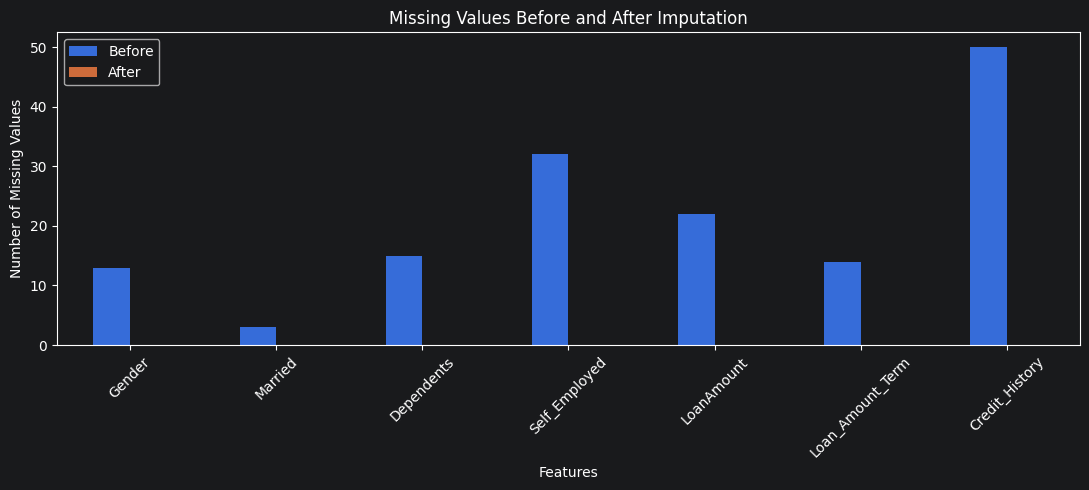

In [16]:
missing_after_train = train_df.isna().sum()
missing_after_test = test_df.isna().sum()

missing_comparison = pd.DataFrame({
    "Before": missing_before_train,
    "After": missing_after_train
})

missing_comparison = missing_comparison[missing_comparison["Before"] > 0]

missing_comparison.plot(kind="bar",figsize=(11, 5))

plt.title("Missing Values Before and After Imputation")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.legend(title="")
plt.tight_layout()

plt.savefig("plots/missing_values_before_after.png", dpi=300, bbox_inches="tight")

plt.show()

## 9. Identifier Removal

`Loan_ID` uniquely identifies each application but does not provide
predictive information about loan approval.

It is therefore removed from both datasets before modeling.

In [17]:
train_df = train_df.drop(columns=[id_col])
test_df = test_df.drop(columns=[id_col])

print("Loan_ID dropped")
print(train_df.shape)
print(test_df.shape)

Loan_ID dropped
(614, 12)
(367, 11)


## 10. Feature Engineering

Three domain-inspired features are created to capture relationships that
may be more informative than the original variables alone.

### Total Income

Combines applicant and coapplicant income:

`totalIncome = ApplicantIncome + CoapplicantIncome`

### Income per Dependent

Approximates the income available per household dependent.

### Loan-to-Income Ratio

Measures the loan amount relative to the applicant's total income.

These features attempt to capture financial capacity and repayment burden.

In [18]:
train_df = prepare_dependents(train_df)
test_df = prepare_dependents(test_df)

In [19]:
train_df = add_engineered_features(train_df)
test_df = add_engineered_features(test_df)

In [20]:
(train_df[["ApplicantIncome","CoapplicantIncome","Dependents","totalIncome","incomePerDependent","LoanAmount","loanToIncomeRatio"]].head())

,ApplicantIncome,CoapplicantIncome,Dependents,totalIncome,incomePerDependent,LoanAmount,loanToIncomeRatio
0,5849,0.000,0,5849.000,5849.000,128.000,0.022
1,4583,1508.000,1,6091.000,3045.500,128.000,0.021
2,3000,0.000,0,3000.000,3000.000,66.000,0.022
3,2583,2358.000,0,4941.000,4941.000,120.000,0.024
4,6000,0.000,0,6000.000,6000.000,141.000,0.024


## 11. Categorical Variable Representation

Although `Dependents` can be represented numerically after converting
`3+` to `3`, it is treated as categorical for modeling.

This avoids imposing a strictly linear relationship between the number
of dependents and the probability of loan approval.

The categorical variables will therefore be one-hot encoded.

## 12. Feature–Target Separation

The target variable is separated from the explanatory variables before
encoding and scaling.

For binary classification, `Loan_Status` is encoded as:

- `N → 0`
- `Y → 1`

In [21]:
X_train = train_df.drop(columns=["Loan_Status"])
y_train = train_df["Loan_Status"].map({"N": 0, "Y": 1})

In [22]:
y_train.head()

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64

## 13. One-Hot Encoding of Categorical Features

One-hot encoding converts categorical variables into binary indicator
variables without introducing an artificial numerical ordering.

`drop_first=True` is used to avoid redundant dummy variables for
binary/multi-category features.

In [23]:
categorical_cols = ["Gender","Married","Dependents","Education","Self_Employed","Property_Area"]

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols,drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True, dtype=int)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [25]:
print("Train shape:", X_train_encoded.shape)
print("Test shape :", X_test_encoded.shape)
print("\nSame feature columns:",X_train_encoded.columns.equals(X_test_encoded.columns))

Train shape: (614, 17)
Test shape : (367, 17)

Same feature columns: True


## 14. Numerical Feature Selection for Scaling

Only continuous numerical variables are scaled.

Binary indicators and categorical dummy variables remain represented as
0/1 values.

This preserves the interpretation of binary features while standardizing
the scale of continuous financial variables.

In [26]:
scaling_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "totalIncome", "incomePerDependent", "loanToIncomeRatio"]

print("Features to scale:")
print(scaling_cols)

Features to scale:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'totalIncome', 'incomePerDependent', 'loanToIncomeRatio']


In [27]:
train_df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,totalIncome,incomePerDependent,loanToIncomeRatio
count,614.000,614.000,614.000,614.000,614.000,614.000,614.000,614.000,614.000
mean,0.744,5403.459,1621.246,145.752,342.410,0.855,7024.705,5024.998,0.024
std,1.010,6109.042,2926.248,84.107,64.429,0.352,6458.664,4757.062,0.009
min,0.000,150.000,0.000,9.000,12.000,0.000,1442.000,457.500,0.003
25%,0.000,2877.500,0.000,100.250,360.000,1.000,4166.000,2354.375,0.019
50%,0.000,3812.500,1188.500,128.000,360.000,1.000,5416.500,4166.000,0.024
75%,1.000,5795.000,2297.250,164.750,360.000,1.000,7521.750,6000.000,0.028
max,3.000,81000.000,41667.000,700.000,480.000,1.000,81000.000,63337.000,0.083


## 15. Robust Scaling

`RobustScaler` is selected because several financial variables exhibit
strongly asymmetric distributions and extreme values.

For example, the original training data contains:

- `ApplicantIncome` with a maximum of 81,000 compared with a median of 3,812.5
- `CoapplicantIncome` with a maximum of 41,667 compared with a median of 1,188.5
- `LoanAmount` with a maximum of 700 compared with a median of 128

RobustScaler uses the median and interquartile range (IQR), making it
less sensitive to extreme observations than mean/std-based scaling.

In [28]:
X_train_before_scaling = X_train_encoded[scaling_cols].copy()
X_test_before_scaling = X_test_encoded[scaling_cols].copy()

## 16. Feature Scaling  Train-Fitted Transformation

The scaler is fitted exclusively on the training data.

The learned transformation is then applied to both the training and test
datasets.

This ensures that the test distribution does not influence preprocessing.

In [29]:
scaler = RobustScaler()
X_train_encoded[scaling_cols] = scaler.fit_transform(X_train_encoded[scaling_cols])
X_test_encoded[scaling_cols] = scaler.transform(X_test_encoded[scaling_cols])

## 17. Scaling Impact

Boxplots are used to compare the distributions of continuous variables
before and after RobustScaler.

The objective is not to make every variable identical, but to put the
continuous features on a more comparable scale while reducing the
influence of extreme values.

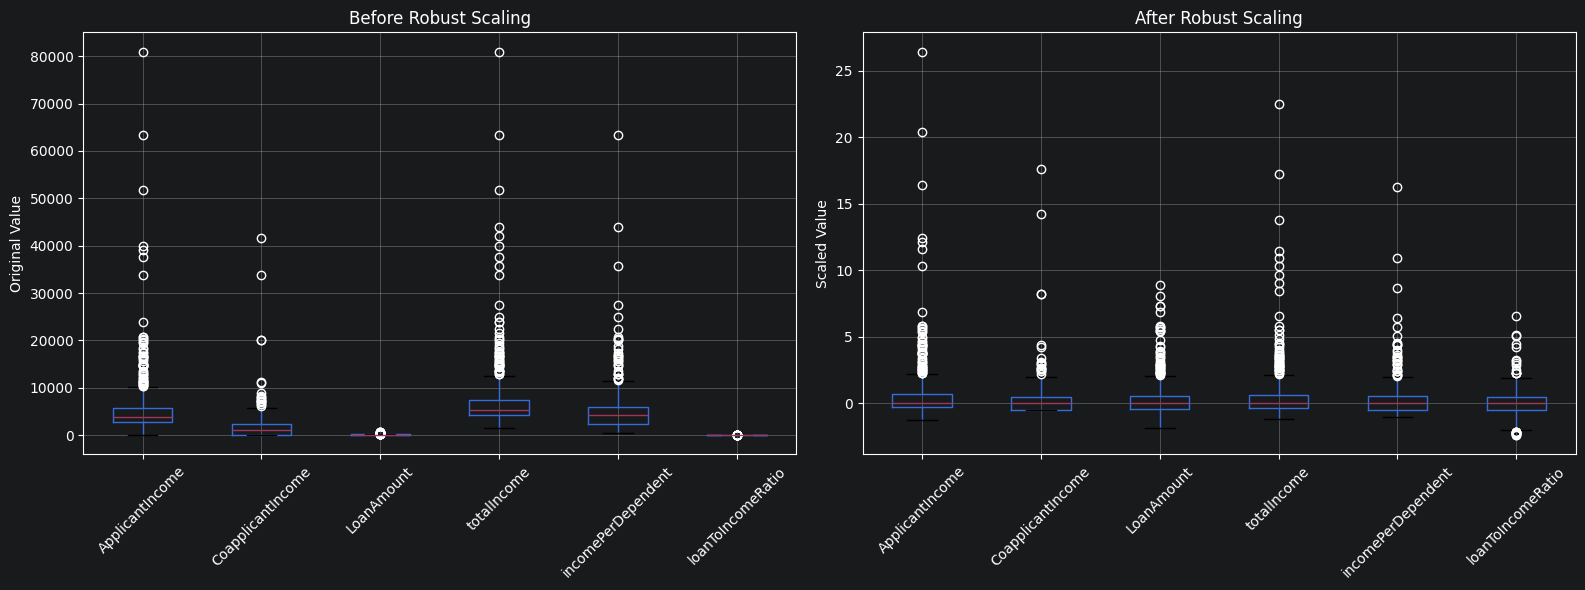

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

X_train_before_scaling.boxplot(ax=axes[0])
axes[0].set_title("Before Robust Scaling")
axes[0].set_ylabel("Original Value")
axes[0].tick_params(axis="x", rotation=45)

X_train_encoded[scaling_cols].boxplot(ax=axes[1])
axes[1].set_title("After Robust Scaling")
axes[1].set_ylabel("Scaled Value")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig("plots/scaling_effects.png", dpi=300, bbox_inches="tight")

plt.show()

## 18. Scaling Verification

The median and interquartile range are inspected before and after
transformation to verify that RobustScaler has been applied correctly.

In [31]:
scaling_summary = pd.DataFrame({
    "Median Before": X_train_before_scaling.median(),

    "IQR Before": (X_train_before_scaling.quantile(0.75)
        - X_train_before_scaling.quantile(0.25)),

    "Median After": X_train_encoded[scaling_cols].median(),

    "IQR After": (X_train_encoded[scaling_cols].quantile(0.75)
        - X_train_encoded[scaling_cols].quantile(0.25))
})

display(scaling_summary.round(3))

,Median Before,IQR Before,Median After,IQR After
ApplicantIncome,3812.500,2917.500,0.000,1.000
CoapplicantIncome,1188.500,2297.250,0.000,1.000
LoanAmount,128.000,64.500,0.000,1.000
totalIncome,5416.500,3355.750,0.000,1.000
incomePerDependent,4166.000,3645.625,0.000,1.000
loanToIncomeRatio,0.024,0.009,-0.000,1.000


## 19. Final Preprocessed Dataset

The final datasets are inspected to verify:

- identical feature spaces
- absence of missing values
- numerical representation of all features
- correct target encoding
- expected dimensions

In [32]:
print("TRAIN")
print("=" * 50)
print("Shape:", X_train_encoded.shape)
print("Missing:", X_train_encoded.isna().sum().sum())

print("\nTEST")
print("=" * 50)
print("Shape:", X_test_encoded.shape)
print("Missing:", X_test_encoded.isna().sum().sum())

print("\nFeature consistency:")
print("Train/Test columns identical:",X_train_encoded.columns.equals(X_test_encoded.columns))

TRAIN
Shape: (614, 17)
Missing: 0

TEST
Shape: (367, 17)
Missing: 0

Feature consistency:
Train/Test columns identical: True


In [33]:
(y_train.head())

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64

In [34]:
display(X_train_encoded.head())
display(X_test_encoded.head())

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,totalIncome,incomePerDependent,loanToIncomeRatio,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.698,-0.517,0.000,360.000,1.000,0.129,0.462,-0.251,1,0,0,0,0,0,0,0,1
1,0.264,0.139,0.000,360.000,1.000,0.201,-0.307,-0.348,1,1,1,0,0,0,0,0,0
2,-0.278,-0.517,-0.961,360.000,1.000,-0.720,-0.320,-0.238,1,1,0,0,0,0,1,0,1
3,-0.421,0.509,-0.124,360.000,1.000,-0.142,0.213,0.018,1,1,0,0,0,1,0,0,1
4,0.750,-0.517,0.202,360.000,1.000,0.174,0.503,-0.070,1,0,0,0,0,0,0,0,1


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,totalIncome,incomePerDependent,loanToIncomeRatio,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.654,-0.517,-0.279,360.000,1.000,0.090,0.426,-0.548,1,1,0,0,0,0,0,0,1
1,-0.252,0.136,-0.031,360.000,1.000,-0.250,-0.515,0.381,1,1,1,0,0,0,0,0,1
2,0.407,0.266,1.240,360.000,1.000,0.412,-0.521,0.723,1,1,0,1,0,0,0,0,1
3,-0.505,0.591,-0.434,360.000,1.000,-0.158,-0.696,-0.410,1,1,0,1,0,0,0,0,1
4,-0.184,-0.517,-0.775,360.000,1.000,-0.638,-0.244,-0.036,1,0,0,0,0,1,0,0,1


## 20. Correlation Analysis

Correlation analysis is used as an exploratory diagnostic to identify
linear relationships between numerical/encoded features and the target.

The analysis is interpreted cautiously because:

1. correlation does not imply causation;
2. one-hot encoded variables represent categories;
3. engineered variables are mathematically related to their source variables.

Strong correlations between engineered features and their source
variables are therefore expected.

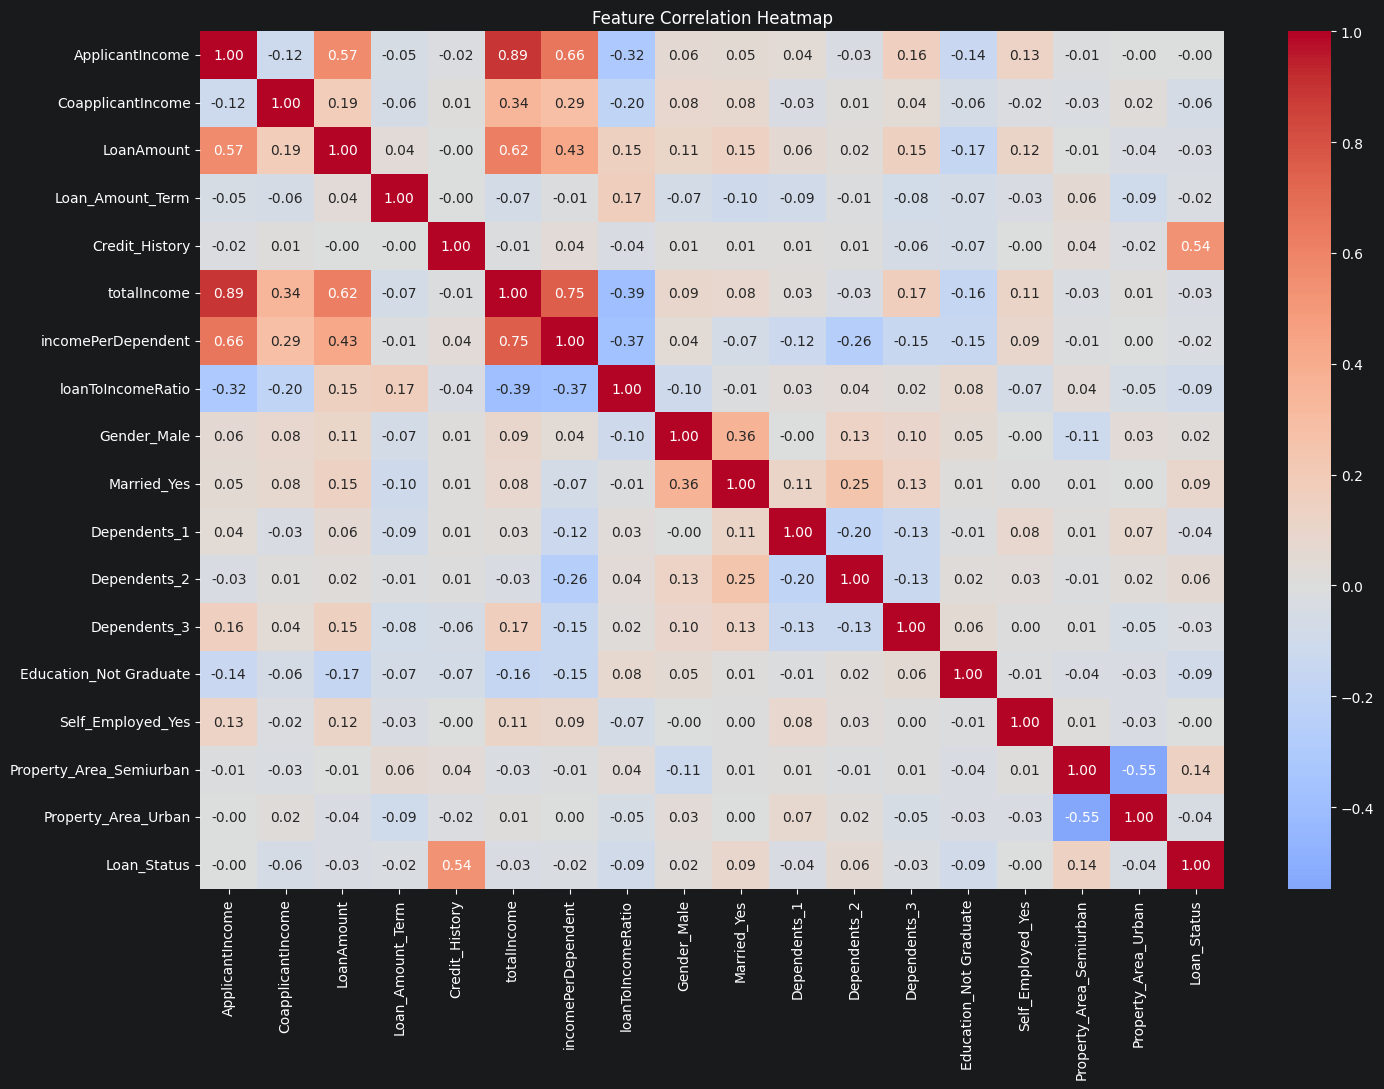

In [35]:
corr_df = pd.concat([X_train_encoded, y_train.rename("Loan_Status")],axis=1)

correlation_matrix = corr_df.corr()

plt.figure(figsize=(15, 11))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [36]:
target_corr = correlation_matrix["Loan_Status"].drop("Loan_Status").abs().sort_values(ascending=False)
display(target_corr.to_frame("Absolute Correlation"))

,Absolute Correlation
Credit_History,0.541
Property_Area_Semiurban,0.137
Married_Yes,0.091
loanToIncomeRatio,0.086
Education_Not Graduate,0.086
Dependents_2,0.062
CoapplicantIncome,0.059
Property_Area_Urban,0.044
Dependents_1,0.039
LoanAmount,0.033


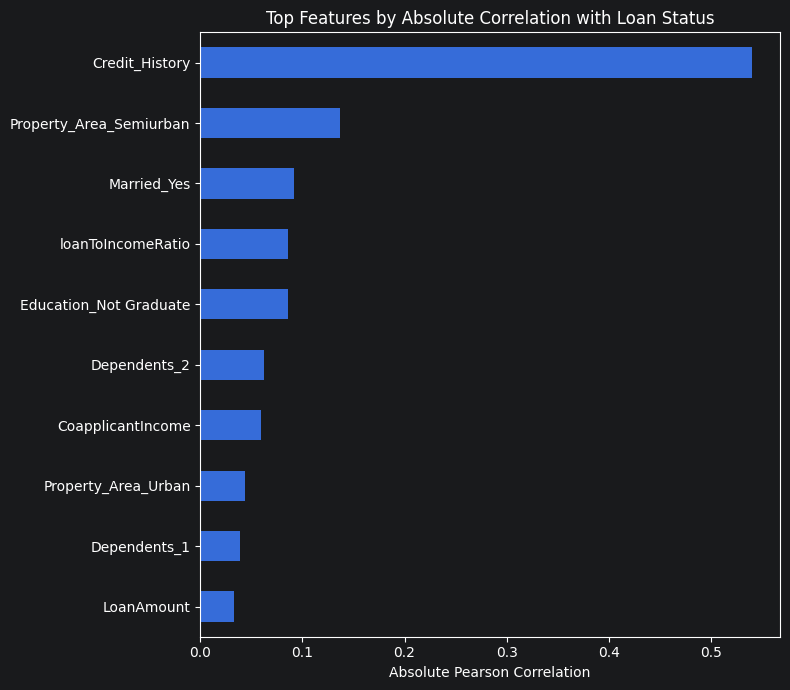

In [37]:
plt.figure(figsize=(8, 7))

target_corr.head(10).sort_values().plot(kind="barh")

plt.title("Top Features by Absolute Correlation with Loan Status")
plt.xlabel("Absolute Pearson Correlation")
plt.tight_layout()

plt.savefig("plots/target_correlations.png", dpi=300, bbox_inches="tight")

plt.show()

## 21. Preprocessing Summary

The preprocessing pipeline performed the following transformations:

| Step | Action |
|---|---|
| Data quality | Missing-value and duplicate analysis |
| Identifier | Removed `Loan_ID` |
| Missing values | Mode imputation for categorical/discrete variables |
| Missing values | Median imputation for `LoanAmount` |
| Feature engineering | Created `totalIncome` |
| Feature engineering | Created `incomePerDependent` |
| Feature engineering | Created `loanToIncomeRatio` |
| Categorical encoding | One-hot encoding |
| Target encoding | `N → 0`, `Y → 1` |
| Scaling | `RobustScaler` on continuous numerical variables |
| Leakage prevention | Scaler and imputation values fitted on training data only |
| Validation | Train/test feature consistency and missing-value checks |

## 22. Export of Preprocessed Data

The final preprocessing outputs are saved for subsequent modeling.

The target variable is retained separately for the training set because
the test dataset does not contain the target.

In [38]:
processed_train = X_train_encoded.copy()
processed_train["Loan_Status"] = y_train
processed_test = X_test_encoded.copy()
processed_train.to_csv("data/loan_train_preprocessed.csv",index=False)
processed_test.to_csv("data/loan_test_preprocessed.csv",index=False)

print("Preprocessed datasets saved successfully.")

Preprocessed datasets saved successfully.


# 23. Conclusion

The dataset has been transformed from its raw form into a machine-learning
ready representation.

The main preprocessing decisions were:

- missing values were imputed using training-derived statistics;
- categorical variables were transformed using one-hot encoding;
- the binary target was encoded as 0/1;
- domain-relevant financial features were engineered;
- RobustScaler was selected to reduce the influence of extreme numerical
  observations;
- preprocessing parameters were learned exclusively from the training set;
- the same transformations were applied to the test set;
- the final train and test datasets contain an identical feature space.

The resulting datasets are ready for the modeling phase.


CREATING VISUALIZATIONS


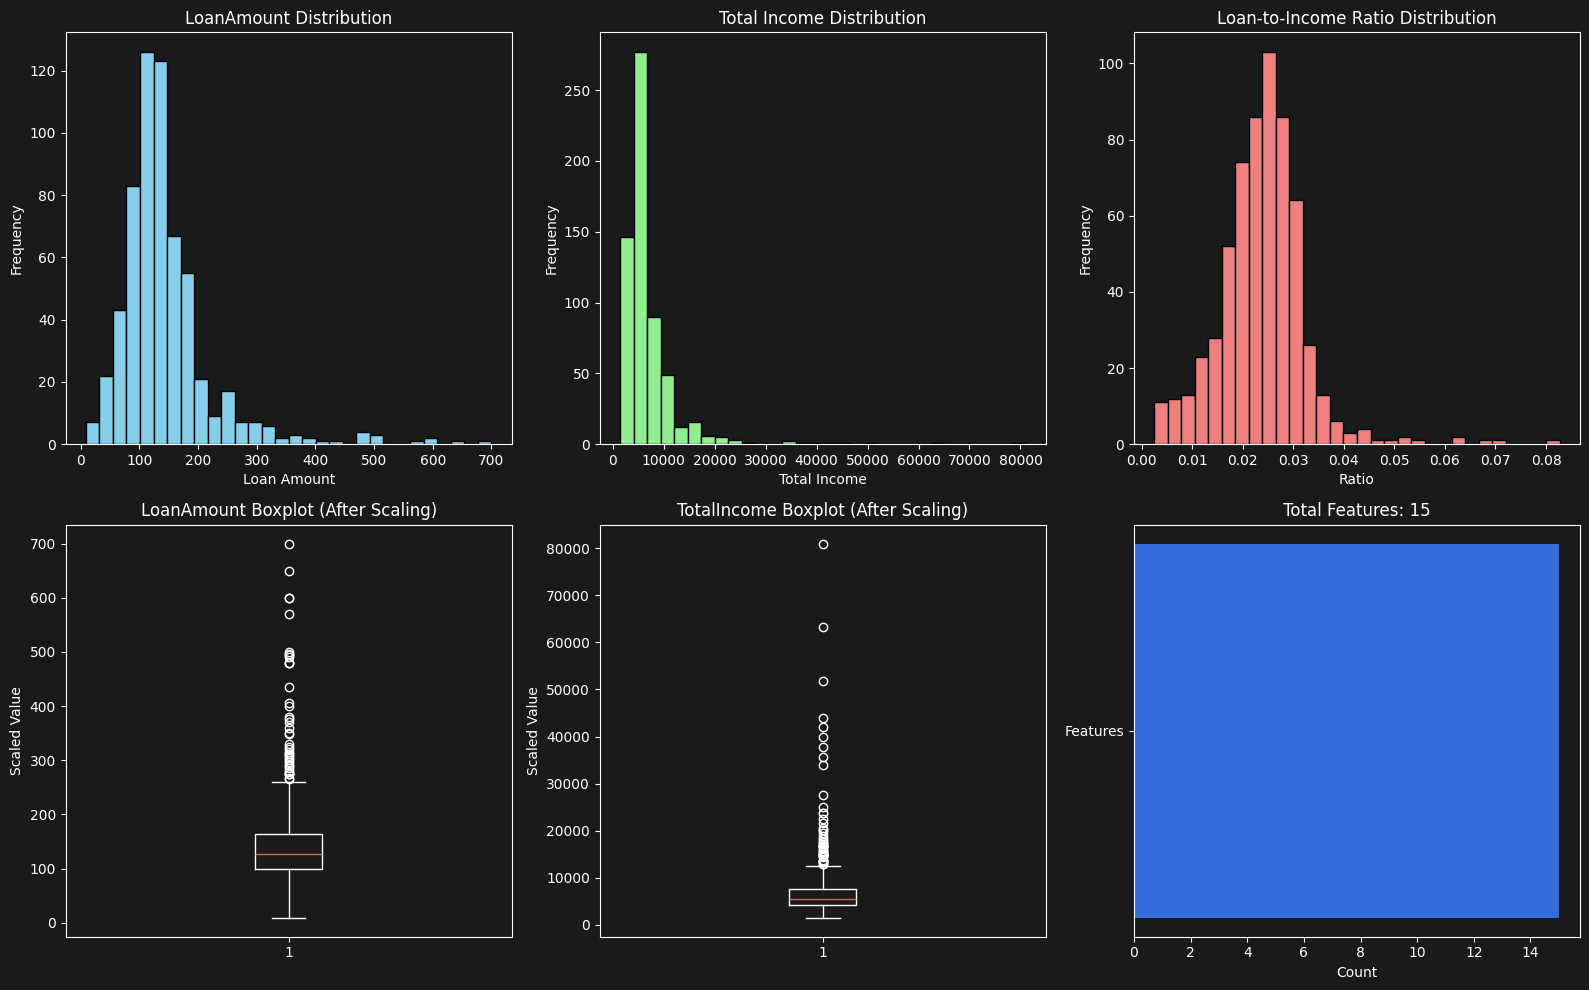

In [39]:
print("\n" + "="*60)
print("CREATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Loan Amount Distribution
axes[0, 0].hist(train_df['LoanAmount'], bins=30, edgecolor='black', color='skyblue')
axes[0, 0].set_title('LoanAmount Distribution')
axes[0, 0].set_xlabel('Loan Amount')
axes[0, 0].set_ylabel('Frequency')

# 2. Total Income Distribution
axes[0, 1].hist(train_df['totalIncome'], bins=30, edgecolor='black', color='lightgreen')
axes[0, 1].set_title('Total Income Distribution')
axes[0, 1].set_xlabel('Total Income')
axes[0, 1].set_ylabel('Frequency')

# 3. Loan to Income Ratio
axes[0, 2].hist(train_df['loanToIncomeRatio'], bins=30, edgecolor='black', color='lightcoral')
axes[0, 2].set_title('Loan-to-Income Ratio Distribution')
axes[0, 2].set_xlabel('Ratio')
axes[0, 2].set_ylabel('Frequency')

# 4. Boxplot - LoanAmount
axes[1, 0].boxplot(train_df['LoanAmount'])
axes[1, 0].set_title('LoanAmount Boxplot (After Scaling)')
axes[1, 0].set_ylabel('Scaled Value')

# 5. Boxplot - TotalIncome
axes[1, 1].boxplot(train_df['totalIncome'])
axes[1, 1].set_title('TotalIncome Boxplot (After Scaling)')
axes[1, 1].set_ylabel('Scaled Value')

# 6. Feature Count
axes[1, 2].barh(['Features'], [len(train_df.columns)])
axes[1, 2].set_title(f'Total Features: {len(train_df.columns)}')
axes[1, 2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('plots/preprocessing_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
df_final = pd.read_csv("../data/loan_train_preprocessed.csv")
df_final = train_df.drop(['ApplicantIncome', 'CoapplicantIncome'], axis=1)
print(f"Dropped redundant income columns")
print(f"Final shape: {df_final.shape}")
print(f"Final features: {list(df_final.columns)}")

Dropped redundant income columns
Final shape: (614, 13)
Final features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'totalIncome', 'incomePerDependent', 'loanToIncomeRatio']


In [53]:
cols = [col for col in df_final.columns if col != 'Loan_Status']
cols.append('Loan_Status')
ml_ready_df = df_final[cols]
ml_ready_df["Loan_Status"] = ml_ready_df["Loan_Status"].map({"N": 0, "Y": 1})

In [56]:
ml_ready_df.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,totalIncome,incomePerDependent,loanToIncomeRatio,Loan_Status
0,Male,No,0,Graduate,No,128.000,360.000,1.000,Urban,5849.000,5849.000,0.022,1
1,Male,Yes,1,Graduate,No,128.000,360.000,1.000,Rural,6091.000,3045.500,0.021,0
2,Male,Yes,0,Graduate,Yes,66.000,360.000,1.000,Urban,3000.000,3000.000,0.022,1
3,Male,Yes,0,Not Graduate,No,120.000,360.000,1.000,Urban,4941.000,4941.000,0.024,1
4,Male,No,0,Graduate,No,141.000,360.000,1.000,Urban,6000.000,6000.000,0.024,1


In [60]:
# Save final ML-ready dataset
ml_ready_df.to_csv('data/loan_ml_ready_dataset.csv', index=False)
ml_ready_df.to_excel('data/loan_ml_ready_dataset.xlsx', index=False)
print(" ML-ready dataset saved!")

 ML-ready dataset saved!
